# Linear Discriminant Analysis (LDA)

---
## Part A — Sample data to understand nuances of LDA


In [1]:
import numpy as np
import pandas as pd
import os

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
W1 = np.array([[4,2],[2,4],[2,3],[3,6],[4,4]])
W2 = np.array([[9,10],[6,8],[9,5],[8,7],[10,8]])

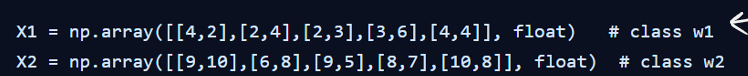

#### Let us try to plot the given `data distribution`

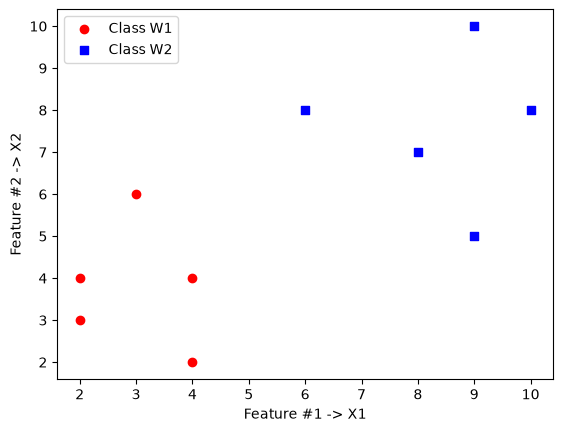

In [11]:
plt.figure()
plt.scatter(W1[:,0], W1[:,1], marker = 'o', color='red', label='Class W1')
plt.scatter(W2[:,0], W2[:,1], marker = 's', color='blue', label ='Class W2')

plt.xlabel("Feature #1 -> X1")
plt.ylabel("Feature #2 -> X2")
plt.legend()
plt.show()

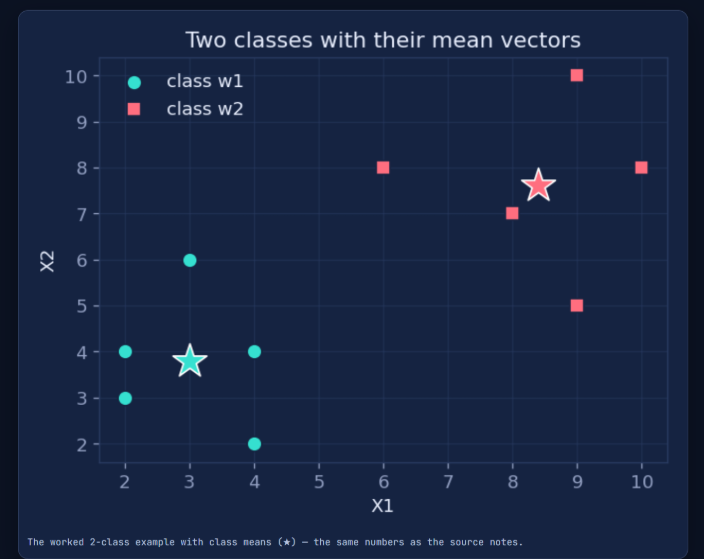

### `Step#1` - Calculate the `mean for each of the classes`

In [12]:
### Class Means
mu1 = W1.mean(axis=0) #class mean for W1
mu2 = W2.mean(axis=0) #class mean for W2
print("Class W1 mean is:", mu1)
print("Class W2 mean is:", mu2)


Class W1 mean is: [3.  3.8]
Class W2 mean is: [8.4 7.6]


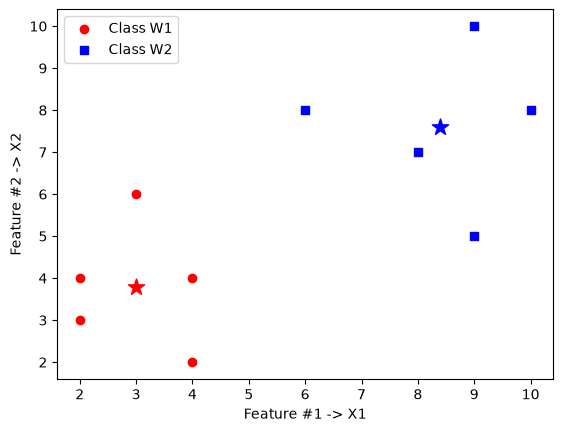

In [13]:
### Let us also add the class means in the above scatter plot
plt.figure()
plt.scatter(W1[:,0], W1[:,1], marker = 'o', color='red', label='Class W1')
plt.scatter(W2[:,0], W2[:,1], marker = 's', color='blue', label ='Class W2')

### Add the class means
plt.scatter(mu1[0], mu1[1], marker = '*', s=150, color='red') # Class W1 Mean
plt.scatter(mu2[0], mu2[1], marker = '*', s=150, color='blue') # Class W2 Mean

plt.xlabel("Feature #1 -> X1")
plt.ylabel("Feature #2 -> X2")
plt.legend()
plt.show()

### `Step#2` - `With-in class scatter`

In [14]:
S1_cov = sum(np.outer(x - mu1, x - mu1) for x in X1)/(len(X1)-1) #cov--> co-variance
S2_cov = sum(np.outer(x - mu2, x - mu2) for x in X2)/(len(X2)-1)
Sw = S1_cov + S2_cov

In [15]:
S1_cov 

array([[ 1.  , -0.25],
       [-0.25,  2.2 ]])

In [16]:
S2_cov

array([[ 2.3 , -0.05],
       [-0.05,  3.3 ]])

In [17]:
Sw

array([[ 3.3, -0.3],
       [-0.3,  5.5]])

### `Step#3` - `Between class scatter`

In [18]:
mean_diff = (mu1 - mu2).reshape(-1,1)
mean_diff

array([[-5.4],
       [-3.8]])

In [21]:
Sb = mean_diff @ mean_diff.T
Sb

array([[29.16, 20.52],
       [20.52, 14.44]])

### `Step#4` - `Eigen Decomposition`

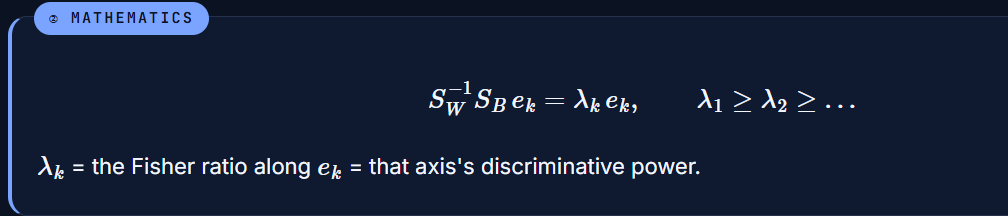

In [27]:
eigvals, eigvecs = np.linalg.eig(np.linalg.inv(Sw)@Sb)

In [28]:
print("Eigen Values:", eigvals)

Eigen Values: [12.20066445  0.        ]


In [29]:
print("Eigen Vectors:", eigvecs)

Eigen Vectors: [[ 0.90878558 -0.57549341]
 [ 0.41726342  0.81780642]]


### `Step#5` - `Projection of Data`

In [30]:
w = eigvecs[:, np.argmax(eigvals)]
w #gives you the direction in which data needs to be projected in

array([0.90878558, 0.41726342])

In [31]:
w = w/np.linalg.norm(w) #unit vector

In [32]:
w

array([0.90878558, 0.41726342])

In [33]:
### let us project the data
Y1 = W1 @ w
Y2 = W2 @ w

print(Y1)
print(Y2)

[4.46966918 3.48662485 3.06936143 5.22993727 5.30419602]
[12.35170446  8.79082087 10.26538736 10.19112861 12.4259632 ]


In [34]:
from scipy.stats import norm

- #### Below code is generated using `AI tool` as a quick assistance

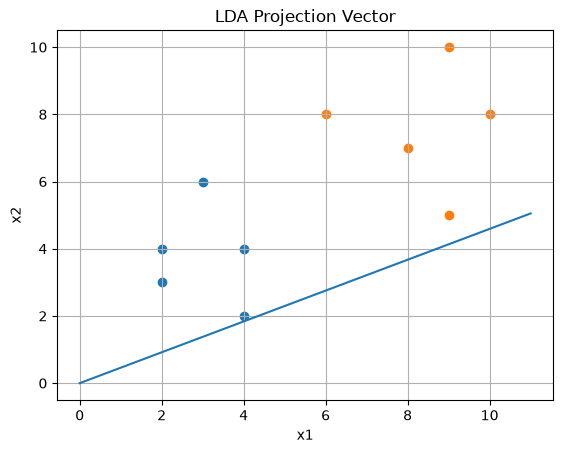

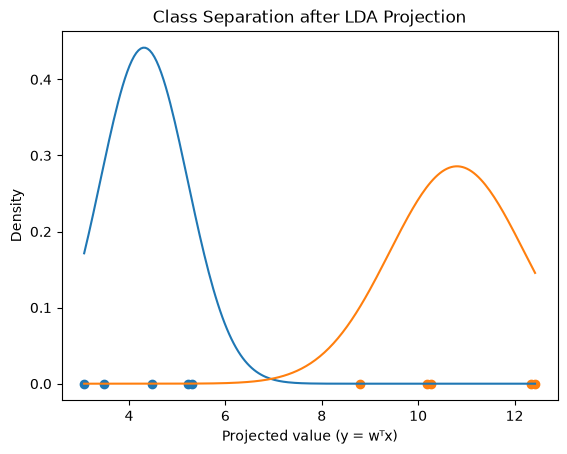

In [36]:
# Plot projection vector
plt.figure()
plt.scatter(W1[:,0], W1[:,1])
plt.scatter(W2[:,0], W2[:,1])

x_vals = np.linspace(0, 11, 100)
y_vals = (w[1] / w[0]) * x_vals
plt.plot(x_vals, y_vals)

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("LDA Projection Vector")
plt.grid(True)
plt.show()

# Plot 1D projected distributions
plt.figure()

x_axis = np.linspace(min(np.concatenate([Y1,Y2])),
                     max(np.concatenate([Y1,Y2])), 200)

plt.plot(x_axis, norm.pdf(x_axis, Y1.mean(), Y1.std()))
plt.plot(x_axis, norm.pdf(x_axis, Y2.mean(), Y2.std()))

plt.scatter(Y1, np.zeros_like(Y1))
plt.scatter(Y2, np.zeros_like(Y2))

plt.xlabel("Projected value (y = wᵀx)")
plt.ylabel("Density")
plt.title("Class Separation after LDA Projection")
plt.show()

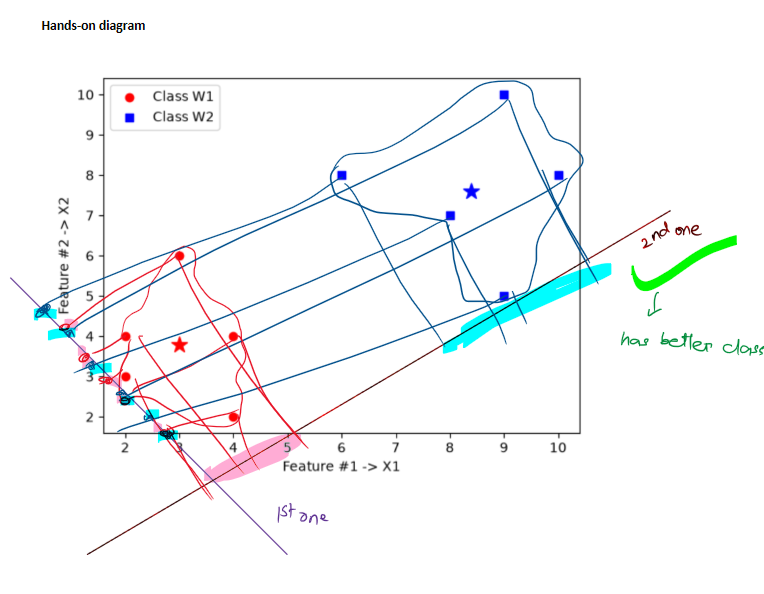

- https://www.khanacademy.org/math/linear-algebra

---
## Part B — LDA on Digits Dataset (sklearn)

**Setup:** `1797` images of handwritten digits (0–9), each 8×8 pixels = **64 features**.
LDA reduces this to **9 discriminants** (n_classes − 1 = 10 − 1 = 9), then Random Forest classifies.

In [37]:
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis # Importing LDA from sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

digits = datasets.load_digits()
print('Dataset shape:', digits.data.shape)
print('Classes      :', np.unique(digits.target))
print('Samples/class:', {c: (digits.target==c).sum() for c in range(10)})

Dataset shape: (1797, 64)
Classes      : [0 1 2 3 4 5 6 7 8 9]
Samples/class: {0: np.int64(178), 1: np.int64(182), 2: np.int64(177), 3: np.int64(183), 4: np.int64(181), 5: np.int64(182), 6: np.int64(181), 7: np.int64(179), 8: np.int64(174), 9: np.int64(180)}


### Sample Images from the Dataset

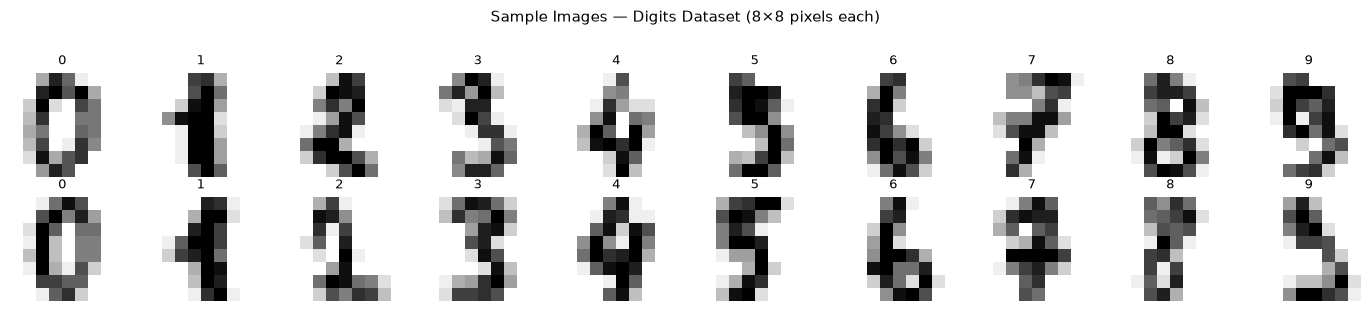

In [38]:
fig, axes = plt.subplots(2, 10, figsize=(14, 3))
for i, (ax, img, lbl) in enumerate(zip(axes.flat, digits.images, digits.target)):
    ax.imshow(img, cmap='gray_r', interpolation='nearest')
    ax.set_title(str(lbl), fontsize=9)
    ax.axis('off')
plt.suptitle('Sample Images — Digits Dataset (8×8 pixels each)', fontsize=11, y=1.02)
plt.tight_layout();  plt.show()

### Data Preparation — Split & Scale

In [39]:
X = digits.data
y = digits.target

print(f'Feature matrix X : {X.shape}  (1797 samples × 64 pixel features)')
print(f'Target vector  y : {y.shape}  (10 digit classes)')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit only on train
X_test_sc  = scaler.transform(X_test)        # apply same scale to test

print(f'\nTrain set : {X_train_sc.shape}  ({X_train.shape[0]/X.shape[0]*100:.0f}% of data)')
print(f'Test  set : {X_test_sc.shape}   ({X_test.shape[0]/X.shape[0]*100:.0f}% of data)')
print(f'After scaling — mean: {X_train_sc.mean():.4f}, std: {X_train_sc.std():.4f}')

Feature matrix X : (1797, 64)  (1797 samples × 64 pixel features)
Target vector  y : (1797,)  (10 digit classes)

Train set : (1437, 64)  (80% of data)
Test  set : (360, 64)   (20% of data)
After scaling — mean: 0.0000, std: 0.9763


### Baseline - with `**NO**`dimensionality reduction
- Before applying LDA we establish a baseline model: train a RandomForest on all 64 raw(scaled) features

In [40]:
rf_base = RandomForestClassifier(n_estimators=100, random_state=42)
rf_base.fit(X_train_sc, y_train)
acc_base = accuracy_score(y_test, rf_base.predict(X_test_sc))
print(f'Baseline RF (64 features) accuracy: {acc_base*100:.2f}%')

Baseline RF (64 features) accuracy: 96.39%


### LDA — Reduce 64 Features → 9 Discriminants

LDA finds the **9 linear combinations** of the 64 features that best separate the 10 digit classes.
Maximum possible = `n_classes − 1 = 10 − 1 = **9**.`

In [42]:
lda = LinearDiscriminantAnalysis(n_components=9)
X_train_lda = lda.fit_transform(X_train_sc, y_train)
X_test_lda = lda.transform(X_test_sc)

print(f'Before LDA: {X_train_sc.shape}  →  After LDA: {X_train_lda.shape}')
print(f'Feature reduction: 64 → 9  ({(1-9/64)*100:.0f}% fewer features!)')
print(f'\nExplained variance ratio per discriminant:')
for i, ev in enumerate(lda.explained_variance_ratio_):
    bar = '█' * int(ev * 50)
    print(f'  LD{i+1}: {ev*100:5.1f}%  {bar}')
print(f'\nTotal variance explained: {lda.explained_variance_ratio_.sum()*100:.2f}%')

Before LDA: (1437, 64)  →  After LDA: (1437, 9)
Feature reduction: 64 → 9  (86% fewer features!)

Explained variance ratio per discriminant:
  LD1:  29.0%  ██████████████
  LD2:  18.6%  █████████
  LD3:  16.9%  ████████
  LD4:  11.3%  █████
  LD5:   8.3%  ████
  LD6:   6.7%  ███
  LD7:   4.2%  ██
  LD8:   3.0%  █
  LD9:   2.1%  █

Total variance explained: 100.00%


### Random Forest on LDA-Reduced Data

In [43]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_lda, y_train)

y_pred = rf.predict(X_test_lda)
acc_lda = accuracy_score(y_test, y_pred)

print(f'LDA (9 components) + RF accuracy: {acc_lda*100:.2f}%')
print(f'Baseline RF (64 features)        : {acc_base*100:.2f}%')
print(f'Difference                        : {(acc_lda - acc_base)*100:+.2f}%')
print(f'Feature reduction                 : 64 → 9  ({(1-9/64)*100:.0f}% fewer features)')

LDA (9 components) + RF accuracy: 96.11%
Baseline RF (64 features)        : 96.39%
Difference                        : -0.28%
Feature reduction                 : 64 → 9  (86% fewer features)
